ESEMPIO IMPLEMENTAZIONE VAE IN PYTORCH

Implementare un VAE non è come scrivere un classificatore standard, richiede di sapere manipolare il grafo computazionale  per far convivere la stocasticità con il calcolo dei gradienti.

- Metodo Custom: implementazione della reparametrization, che è il cuore pulsante che permetta a pytorch di campionare pur restando derivabili.
- Addestramento End-to-End: la loss combinata tra pixel e distribuzioni, per bilanciare la qualità dell'immagine con la regolarità statistica.
- KL Annealing: strategie per evitare che il nostro modello collassi prima ancora di aver imparato qualcosa.

Partiamo dalla sfida tecnica principale: come inseriamo il caso all'interno di una rete neurale.

Campionamento e Reparameterization
Integrare la stocasticità in nn.Module
In PyTorch, l'implementazione del VAE richiede la definizione di un metodo specifico all'interno della classe 'nn.Module' per gestire il passaggio dello spazio dei parametri allo spazio campionario.
Dobbiamo isolare il nodo stocastico per permettere ad Autograd di calcolare correttamente i gradienti necessari all'aggiornamento dell'encoder.
La differenza rispetto ad un AutoEncoder classico è che l'encoder non è una linea retta verso il codice, ma un bivio che produce due parametri.
Dobbiamo definire un metodo specifico, che sappia gestire il passaggio dallo spazio dei parametri, media e varianza, allo spazio campionario.
Questo metodo deve essere trasparende per Autograd.
Immagina di voler inserire una variabile casuale in una catena di montaggio senza bloccare il nastro trasportatore, che riporta indietro le informazioni sugli errori.

Vediamo come questo isolamento del nodo stocastico avviene matematicamente all'interno del codice.

Il Metodo di Campionamento
Isolare epsilon nel grafo
L'encoder produce due output distinti: un tensore per le medie e uno per il logaritmo delle varianze. 
Per generare z usiamo rumore casuale
Il rumore casuale viene generato esternamente tramite torch.randn_like per mantenere la stessa forma dei parametri.
Nota che z è una condizione deterministica dei parametri appresi.
Il rumore entra solo come un fattore esterno, come fosse un tensore che giunge un disturno ad un segnale radio.
L'operazione di moltiplicazione per la deviazione standard e addizione della media è l'unico punto di contatto tra rumore e parametri.
Questa struttura garantisce che il cammino della backpropagation resti interamente deterministico rispetto ai pesi della rete.

La struttura del modello segue un flusso logico preciso.
Il codice latente 'z' appena campionato, diventa l'input per il primo layer del decoder, proprio come un codice di un autoencoder classico (Input in nn.Linear).
Utilizziamo il logaritmo della varianza per permettere alla rete di produrre valori in tutto l'asse reale, garantendo stabilità numerica.
Il flusso dati attraversa encoder, campionamento e decoder restituendo sia la ricostruzione, immagine ricostruita, che i parametri della distribuzione, media e log varianza (metodo forward).
Immagine ricostruita, media e log varianza ci serviranno tutti per calcolare la perdita finale.

Ora che sappiamo come campionare, dobbiamo definire come punire gli errori.

La Funzione di Perdita Combinata
Bilanciare fedeltà visiva e regolarità statistica.
L'addestramento del VAE in PyTorch richiede una loss function personalizzata che non esiste tra i criteri standard della libreria.
Non troverai nn.VAELoss nella documentazione di pytorch, dobbiamo costruirla noi, unendo due mondi.
Da un lato abbiamo la fedeltà visiva, vogliamo che i pixel siano al posto giusto, dall'altro abbiamo la regolarità statistica, in modo che lo spazio latente sia compatto.
Dobbiamo combinare la capacità di ricostruzione con un termine di regolarizzazione che forzi l'encoder a organizzare correttamente lo spazio latente.
E' come cerca di dipingere un quadro (puntare alla fedeltà) mentre si cerca di risparmiare il più possibile sulla tela (regolarizzando).
Trovare l'equilibrio tra questi due termini è l'unico modo per avere un modello che generi immagini sensate.

Programmare l'ELBO
Ecco come uniamo BCE e KL Divergence
Il termine di ricostruzione viene spesso calcolato usando F.binary_cross_entropy o F.mse_loss a seconda del dominio dei dati.
La divergenza KL viene implementata manualmente utilizzando i tensori di media e log-varianza prodotti dall'encoder.
E' fondamentale sommare i termini lungo tutte le dimensioni delle feature e fare la media solo alla fine dividendo per la dimensione del batch.
L'obbiettivo è minimizzare la somma dei due termini per trovare il punto di equilibrio tra precisione e densità.

Dettagli Tecnici dell'Implementazione
Il calcolo della ricostruzione deve essere sommato su tutti i pixel per mantenere la corretta proporzione con il termine KL.
La formula in forma chiusa per la KL tra gaussiano evita costose simulazioni di Monte Carlo durante il ciclo di addestramento.
E' buona norma registare separatamente i valori dei due componenti per rilevare squilibri durante le epoche (monitoraggio).

Cosa succede se questo equilibrio non viene raggiunto?

Saturazione e Bilanciamento
Il rischio della ricostruzione perfetta.
C'è un rischio costante, la saturazione.
Se la loss di ricostruzione domina troppo, l'encoder cercherà di imbogliare, il modello ignorerà la KL e tornerà a comportarsi come un autoencoder classico con tutti i suoi buchi nello spazio latente (il VAE smette di essere un modello genereativo). Cercherà di creare punti latenti piccolissimi e lontano tra loro per avere immagini perfette.

Un corretto bilanciamento è l'unico modo per ottenere uno spazio latente che sia realmente campionabile e continuo.

Per aiutare questa danza delicata usiamo un trucco chiamato Annealing

Strategie di KL Annealing
Gestire il riscaldamento del vincolo.
Nelle prime fasi dell'addestramento (training), l'encoder non sa ancora ricostruire i dati (è come un bambino che sta iniziando a scarabocchiare).
Se gli applichiamo subito il vincolo KL, l'encoder si spaventa e potrebbe forzare le distribuzioni allo zero troppo velocemente, per minimizzare la perdita statistica.
Il KL Annealing è la nostra soluzione, è una tecnica di 'warming-up' che introduce gradualmente il peso, inizialmente pari a zero e aumentiamo gradualmente.
Lasciamo che la rete impari prima a disegnare le forme e solo dopo ad essere ordinata.

Il Coefficiente Beta
Dosare la regolarizzazione.
Iniziamo il training con beta pari a zero, permettendo al modello di imparare prima le feature di base.
Aumentiamo linearmente e gradualmente beta fino a 1 (da zero) durante un numero prefissato di iterazioni o epoche.
Inizialmente, quando beta vale quasi zero, la rete si occupa della sola pura fedeltà dell immagine. Quando beta sale, la rete inizia a sentire la pressione statistica e comincia ad organizzare i cluster della classi.
Questa tecnica previene il 'posterior Collapse', ovvero la situazione in cui l'encoder smette di produrre informazioni utili.
Beta agisce come un cursore che sposta il focus della rete dalla pura fedeltà alla struttura semantica.

Evoluzione dello Spazio
Con beta basso, i cluster delle classi si allontanano nello spazio latente per massimizzare la ricostruzione (fase di espansione).
All'aumentare di beta, i cluster sono spinti a comportarsi e a sovrapporsi, creando continuità (fase di compressione).
Strategia moderne prevedono più cicli di annealing per permettere alla rete di affinare i dettagli a diverse scale di regolarità
Con beta basso le classi si allontanano
Quando beta aumenta queste isole (classi) vengono attirate verso l'origine e inizano a compattarsi. E' qui che viene la magia i confini tra le classi iniziano a sovrapporsi in modo coerente. Ed è questa sovraposizione forzata che ci permeterà di generare immmagini fluide passando da un numero all'altro.

Ma attenzione dobbiamo essere pronti a riconoscere i sintomi di un addestramento fallito.

Identificare il Collasso
Sintomi di un addestramento fallito.
Se la KL loss scende improvvisamente a zero e li rimane piatta, l'encoder ha smesso di guardare l'input e il decoder, non ricevendo più informazioni utili, genera solo immagini medie (media di tutto il dataset).
L'uso corretto dell annealing garantisce che l'informazione matua tra input e spazio latente resti sempre elevata.

Immagine 28x28 -> Encoder -> 784->400->200 -> epsilon e logvar -> z -> Decoder -> 32->200->400->784 -> immagine ricostruita


100%|██████████| 26.4M/26.4M [00:04<00:00, 5.95MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.26MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.03MB/s]
Epoca 15: 100%|██████████| 469/469 [00:10<00:00, 43.89it/s, BCE=209, Beta=1, KLD=14.7]


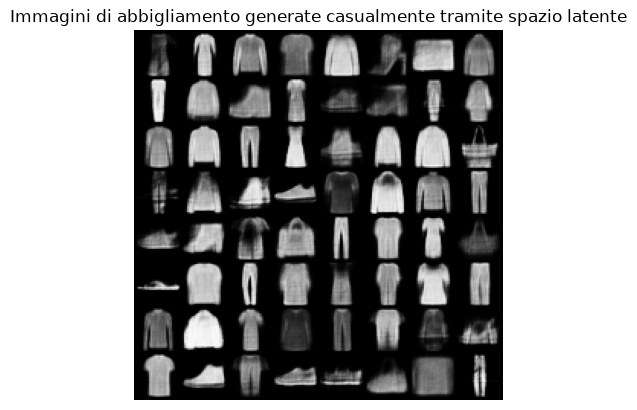

: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader #prende il dataset e lo consegna alla rete a piccoli gruppi (batch)
from tqdm import tqdm #barra di avanzamento
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE E DEFINIZIONE DEGLI IPERPARAMETRI ---
# Selezione del dispositivo di calcolo: utilizza la GPU (cuda) se disponibile per velocizzare l'esecuzione, altrimenti ripiega sulla CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dimensione dello spazio latente: rappresenta il numero di variabili utilizzate per la codifica compressa dell'immagine.
latent_dim = 32 

# Numero di epoche: quante volte l'intero dataset viene passato attraverso il modello durante l'addestramento.
epochs = 15

# Dimensione del batch: numero di immagini processate contemporaneamente prima di ogni aggiornamento dei pesi.
batch_size = 128

# Tasso di apprendimento (Learning Rate): controlla l'entità degli aggiornamenti apportati ai parametri del modello.
lr = 1e-3

# Caricamento e trasformazione dei dati: utilizziamo il dataset Fashion MNIST.
# L'operazione "ToTensor" converte le immagini in tensori di PyTorch scalandone i valori tra 0 e 1.
transform = transforms.Compose([transforms.ToTensor()])
train_loader = DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# --- ARCHITETTURA DEL MODELLO VARIATIONAL AUTOENCODER (VAE) ---
# Il modello implementa un autoencoder variazionale, una rete neurale in grado di apprendere rappresentazioni 
# strutturate dei dati e generare nuovi campioni simili a quelli di addestramento.
class FashionVAE(nn.Module):
    def __init__(self):
        super().__init__()
        
        # L'Encoder analizza l'immagine di input (appiattita in un vettore da 784 elementi) 
        # e ne estrae le caratteristiche principali attraverso strati densi e funzioni di attivazione ReLU.
        self.encoder = nn.Sequential(
            nn.Linear(784, 400), # imput 784 valori, output 400 valori
            nn.ReLU(),
            nn.Linear(400, 200), #secondo strato input 400 valori, output 200 valori
            nn.ReLU()
        )
        
        # Gli strati lineari "fc_mu" e "fc_logvar" trasformano l'output dell'encoder nei parametri di una distribuzione:
        # - mu: la media della distribuzione nello spazio latente.
        # - logvar: il logaritmo della varianza, che definisce l'incertezza della codifica.
        self.fc_mu = nn.Linear(200, latent_dim)
        self.fc_logvar = nn.Linear(200, latent_dim)
        
        # Il Decoder riceve un campione dallo spazio latente e cerca di ricostruire l'immagine originale.
        # L'ultimo strato applica una Sigmoid per garantire che i valori dei pixel siano compatibili con l'input iniziale.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        """
        Applica il metodo di riparametrizzazione.
        Per permettere il passaggio dei gradienti durante il campionamento, separiamo la componente stocastica 
        (epsilon) dai parametri della distribuzione (media e varianza).
        """
        # Calcolo della deviazione standard partendo dal logaritmo della varianza.
        std = torch.exp(0.5 * logvar)
        # Generazione di rumore casuale da una distribuzione normale standard.
        eps = torch.randn_like(std)
        # Trasformazione: calcola il vettore latente z mantenendo la differenziabilità.
        return mu + eps * std

    def forward(self, x):
        """
        Definisce come l'input 'x' attraversa il modello:
        1. L'Encoder codifica l'immagine in parametri statistici.
        2. Viene campionato un vettore 'z' dalla distribuzione risultante.
        3. Il Decoder ricostruisce l'immagine a partire da 'z'.
        """
        # Appiattimento dell'immagine (vettore riga) per l'elaborazione degli strati lineari.
        h = self.encoder(x.view(-1, 784))
        # Estrazione dei parametri mu e logvar.
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        # Campionamento del codice latente tramite riparametrizzazione.
        z = self.reparameterize(mu, logvar)
        # Ritorno del batch ricostruito e dei parametri necessari per il calcolo della loss.
        return self.decoder(z), mu, logvar

# --- FUNZIONE DI PERDITA (LOSS FUNCTION) ---
def loss_function(recon_x, x, mu, logvar, beta):
    """
    Calcola la funzione di costo totale del VAE composta da due termini fondamentali:
    1. Reconstruction Loss (BCE): penalizza il modello se l'output differisce dall'input.
    2. KL Divergence (KLD): obbliga lo spazio latente a seguire una distribuzione normale, 
       favorendo una struttura regolare e utile alla generazione di nuovi dati.
    """
    #Binary cross entropy tra l'immagine originale e la sua ricostruzione.
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    
    # Kullback-Leibler Divergence: quantifica quanto la distribuzione latente calcolata si scosta dalla normale standard.
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Somma pesata delle due loss: il valore beta controlla l'effetto della regolarizzazione.
    return BCE + beta * KLD, BCE, KLD

# --- PROCESSO DI ADDESTRAMENTO ---
# Inizializzazione della rete neurale e spostamento sulla memoria del dispositivo scelto (CPU/GPU).
model = FashionVAE().to(device)
# Ottimizzatore Adam per l'aggiornamento automatico dei pesi basato sulla discesa del gradiente stocastica.
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(epochs):
    model.train() # Imposta il modello in modalità addestramento.
    train_loss = 0
    
    # Calcolo di Beta (KL Annealing): aumentiamo gradualmente l'importanza della regolarizzazione.
    # Nelle fasi iniziali il modello si concentra sulla qualità dell'immagine, successivamente sulla coerenza latente.
    beta = min(1.0, epoch / (epochs * 0.5))
    
    # Barra di avanzamento per monitorare l'andamento del loop corrente.
    pbar = tqdm(train_loader, desc=f"Epoca {epoch+1}")
    for i, (data, _) in enumerate(pbar):
        data = data.to(device)
        # Reset dei gradienti per evitare che si accumulino tra un'iterazione e l'altra.
        optimizer.zero_grad()
        
        # Passaggio dei dati nel modello per ottenere ricostruzioni e parametri latenti.
        recon_batch, mu, logvar = model(data)
        
        # Calcolo della perdita totale attraverso i componenti BCE e KLD.
        loss, bce, kld = loss_function(recon_batch, data, mu, logvar, beta)
        
        # Calcolo dei gradienti tramite procedura di backpropagation.
        loss.backward()
        # Aggiornamento dei parametri della rete neurale.
        optimizer.step()
        
        train_loss += loss.item()
        # Aggiornamento dei dati a schermo per il monitoraggio in tempo reale.
        pbar.set_postfix(BCE=bce.item()/len(data), KLD=kld.item()/len(data), Beta=beta)

# --- VALUTAZIONE E GENERAZIONE DI NUOVI DATI ---
# Disattivazione del calcolo dei gradienti e passaggio alla modalità valutazione.
model.eval()
with torch.no_grad():
    # Per generare nuovi dati, campioniamo casualmente 64 vettori dallo spazio latente.
    # Questi non derivano da immagini reali, ma sono semplici coordinate del 'mondo appreso'.
    sample = torch.randn(64, latent_dim).to(device)
    # Utilizziamo solo il Decoder per trasformare queste coordinate in immagini di capi di abbigliamento.
    sample = model.decoder(sample).cpu()
    
    # Salvataggio della griglia di immagini in formato PNG.
    utils.save_image(sample.view(64, 1, 28, 28), 'fashion_results.png')
    
    # Visualizzazione grafica dei capi generati casualmente.
    plt.imshow(utils.make_grid(sample.view(64, 1, 28, 28)).permute(1, 2, 0))
    plt.title("Immagini di abbigliamento generate casualmente tramite spazio latente")
    plt.axis('off')
    plt.show()